In [ ]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For data manipulation and analysis with DataFrames

# Import scikit-learn modules for machine learning pipeline
from sklearn.model_selection import train_test_split  # Split data into training and testing sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Scale numerical and encode categorical features
from sklearn.compose import ColumnTransformer  # Apply different preprocessing to different column types
from sklearn.pipeline import Pipeline  # Create streamlined ML workflows
from sklearn.ensemble import RandomForestRegressor  # Random Forest algorithm for regression tasks
from sklearn.metrics import root_mean_squared_error, r2_score  # Evaluate model performance metrics

In [2]:
# Load the data science salaries dataset from CSV file
# This dataset contains salary information for data science professionals
df = pd.read_csv('data/ds_salaries.csv')

# Display the shape of the dataset (number of rows and columns)
# This helps us understand the size of our dataset
print(f"Dataset:{df.shape}")
df.head()

Dataset:(3755, 10)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA


In [3]:
# Create a mapping dictionary to convert experience level categories to numeric values
# EN (Entry-level) = 1, MI (Mid-level) = 2, SE (Senior) = 3, EX (Executive) = 4
exp_mapping = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}

# Apply the mapping to convert categorical experience levels to numeric values
df['experience_level'] = df['experience_level'].map(exp_mapping)

In [4]:
# Display comprehensive information about the DataFrame including data types, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   int64 
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
dtypes: int64(5), object(5)
memory usage: 293.5+ KB


In [5]:
# Check for missing values in each column of the dataframe
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
dtype: int64

In [6]:
# Check for duplicate rows in the DataFrame and return a boolean Series
# True indicates the row is a duplicate of a previous row, False indicates it's unique
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3750    False
3751    False
3752    False
3753    False
3754    False
Length: 3755, dtype: bool

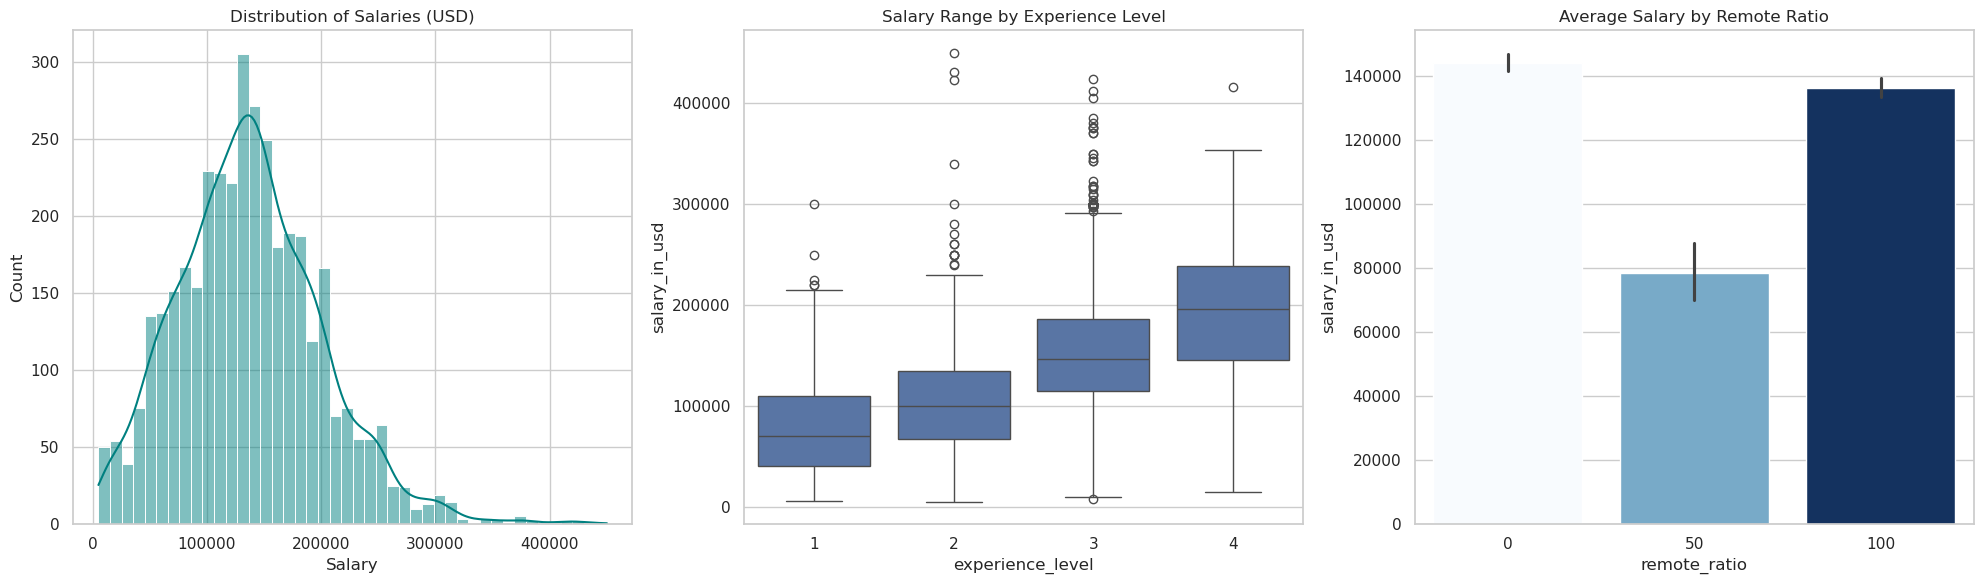

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean visual presentation
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots arranged horizontally
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: Distribution of Salaries
# Create histogram with kernel density estimation overlay to show salary distribution
sns.histplot(df['salary_in_usd'],
             kde=True, 
             ax=axes[0], 
             color='teal')
axes[0].set_title('Distribution of Salaries (USD)')
axes[0].set_xlabel('Salary')

# Plot B: Experience Level vs. Salary
# Order categories logically: Entry (EN), Mid (MI), Senior (SE), Executive (EX)
# exp_order = ['EN', 'MI', 'SE', 'EX']

# colors = sns.color_palette('BuPu', n_colors=len(exp_order))
# palette_dict = dict(zip(exp_order, colors))

# Create box plot to show salary ranges and quartiles for each experience level
# Use hue parameter to apply palette colors and disable legend to avoid deprecation warning
sns.boxplot(data=df, 
            x='experience_level', 
            y='salary_in_usd', 
            # order=exp_order, 
            ax=axes[1], 
            # palette=palette_dict # Using a manual dictionary completely bypasses the bug
           )
axes[1].set_title('Salary Range by Experience Level')

# Plot C: Remote Ratio vs. Salary
# Create bar plot showing average salary for different remote work ratios
# Use hue parameter to apply palette colors and disable legend to avoid deprecation warning
sns.barplot(data=df, 
            x='remote_ratio',
            y='salary_in_usd', 
            ax=axes[2], 
            hue='remote_ratio', 
            palette='Blues', 
            legend=False)
axes[2].set_title('Average Salary by Remote Ratio')

# Adjust subplot spacing to prevent overlap
plt.tight_layout()
# Display the complete figure with all three plots
plt.show()

In [8]:
# Group rare categories into "Other" BEFORE splitting
THRESHOLD = 5

for col in ['job_title', 'company_location', 'employee_residence']:
    counts = df[col].value_counts()
    rare_items = counts[counts < THRESHOLD].index
    df.loc[df[col].isin(rare_items), col] = 'Other'

In [9]:
# Prepare the dataset for machine learning by separating features and target variable
# Create feature matrix (X) by removing all salary-related columns to prevent data leakage
# Data leakage occurs when the model has access to information it shouldn't have during training
X = df.drop(columns=['salary', 'salary_currency', 'salary_in_usd'])
# Define the target variable (y) as the salary converted to USD for consistent prediction
# Convert the target to float so the pipeline knows it's continuous regression
y = df['salary_in_usd'].astype(float)

In [10]:
# 1. Split off the final 20% Test Set
# Use train_test_split to separate 20% of data for final testing
# This creates a holdout set that won't be used during model development
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Split remaining 80% into Train (60% total) and Validation (20% total)
# Split the remaining 80% of data into training and validation sets
# test_size=0.25 means 25% of the 80% remaining data goes to validation
# This results in 60% training and 20% validation of the original dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42  # 0.25 * 0.80 = 0.20
)

In [11]:
# Group rare categories into "Other" BEFORE splitting
THRESHOLD = 5

for col in ['job_title', 'company_location', 'employee_residence']:
    counts = X_train[col].value_counts()
    rare_items = counts[counts < THRESHOLD].index
    X_train.loc[df[col].isin(rare_items), col] = 'Other'

In [12]:
from sklearn.preprocessing import TargetEncoder

# Group columns by type for different preprocessing strategies
categorical_cols = ['employment_type', 'job_title', 
                      'employee_residence', 'company_location']
numeric_cols = ['work_year', 'remote_ratio', 'experience_level']

# Create preprocessing pipeline with different transformers for different data types
# Preprocessing strategy:
# - Numeric: Scale them so work_year or remote_ratio don't skew distances
# - Categorical: One-Hot Encode text. handle_unknown='ignore' prevents crashes if Test has a rare job title
# Notice we can safely put cv=5 back in now, because we guaranteed 
# that every category has at least 5 examples!
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        # Explicitly declare the target type as continuous!
        ('cat_high', TargetEncoder(target_type="continuous", random_state=42), 
         ['job_title', 'company_location', 'employee_residence']),
        ('cat_low', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
         ['experience_level', 'employment_type'])
    ]
)

In [13]:
# Create the pipeline wrapper
# Pipeline ensures preprocessing and model training happen in correct sequence
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # First step: apply data preprocessing transformations
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))  # Second step: Random Forest with 100 trees, fixed seed for reproducibility, use all CPU cores
])

# FIT ONLY ON TRAINING DATA
# This calculates scaling means and learns categories strictly from X_train
# Important: Pipeline learns preprocessing parameters (means, scales, categories) only from training data to prevent data leakage
pipeline.fit(X_train, y_train)  # Train both preprocessor and model on training set

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_high', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
from sklearn.compose import TransformedTargetRegressor

# Wrap your existing pipeline with log transformation for target variable
model_log = TransformedTargetRegressor(
    regressor=pipeline,  # The original regression pipeline to be wrapped
    func=np.log1p,       # Applies log(x + 1) to y_train before fitting
    inverse_func=np.expm1 # Applies exp(x) - 1 to predictions automatically
)

# Fit the model with log-transformed target values
model_log.fit(X_train, y_train)

,regressor,Pipeline(step...m_state=42))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('num', ...), ('cat_high', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [15]:
# Predict on Validation data
# Use the trained pipeline to make predictions on the validation dataset
y_val_pred = model_log.predict(X_val)

# Evaluate performance
# Calculate Root Mean Squared Error to measure prediction accuracy
val_rmse = root_mean_squared_error(y_val, y_val_pred)
# Calculate R-squared score to measure how well the model explains variance
val_r2 = r2_score(y_val, y_val_pred)

# Display validation metrics in a formatted output
print("--- VALIDATION SET METRICS ---")
print(f"Validation RMSE: ${val_rmse:,.2f}")
print(f"Validation R² Score: {val_r2:.4f}")

--- VALIDATION SET METRICS ---
Validation RMSE: $51,598.94
Validation R² Score: 0.3201


In [16]:
# Unlocking the vault: Final unbiased test
# Generate predictions on the test set using the trained pipeline
y_test_pred = model_log.predict(X_test)

# Calculate Root Mean Squared Error to measure prediction accuracy
test_rmse = root_mean_squared_error(y_test, y_test_pred)
# Calculate R-squared score to measure how well the model explains variance
test_r2 = r2_score(y_test, y_test_pred)

# Display final model performance metrics on unseen test data
print("\n--- FINAL TEST SET METRICS ---")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Test R² Score: {test_r2:.4f}")


--- FINAL TEST SET METRICS ---
Test RMSE: $49,814.14
Test R² Score: 0.3714


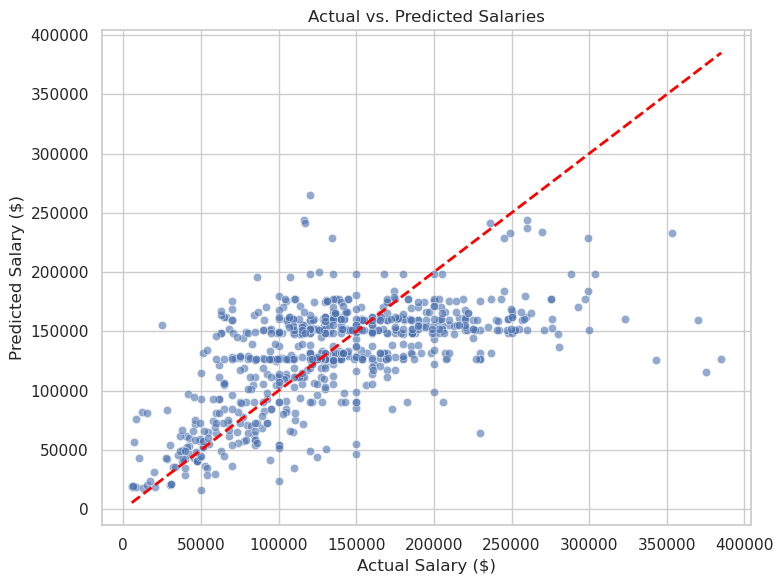

In [17]:
# y_test = actual values, y_test_pred = model's predictions

# Create a figure with specified dimensions for the scatter plot
plt.figure(figsize=(8, 6))

# Create scatter plot comparing actual vs predicted values
# Alpha controls transparency, color sets point color to blue
sns.scatterplot(x=y_test, 
                y=y_test_pred, 
                alpha=0.6, # makes points 60% opaque (40% transparent)
                color='b')

# Plot a diagonal 'perfect prediction' reference line
# Create coordinates for a diagonal line from min to max actual values
perfect_line = [y_test.min(), y_test.max()]
# Draw the diagonal reference line (red dashed line)
# Points on this line represent perfect predictions where actual = predicted
plt.plot(perfect_line, 
         perfect_line, 
         color='red', 
         linestyle='--', 
         linewidth=2)

# Add title and axis labels for clarity
plt.title('Actual vs. Predicted Salaries')
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')

# Adjust layout to prevent label cutoff and display the plot
plt.tight_layout()
plt.show()

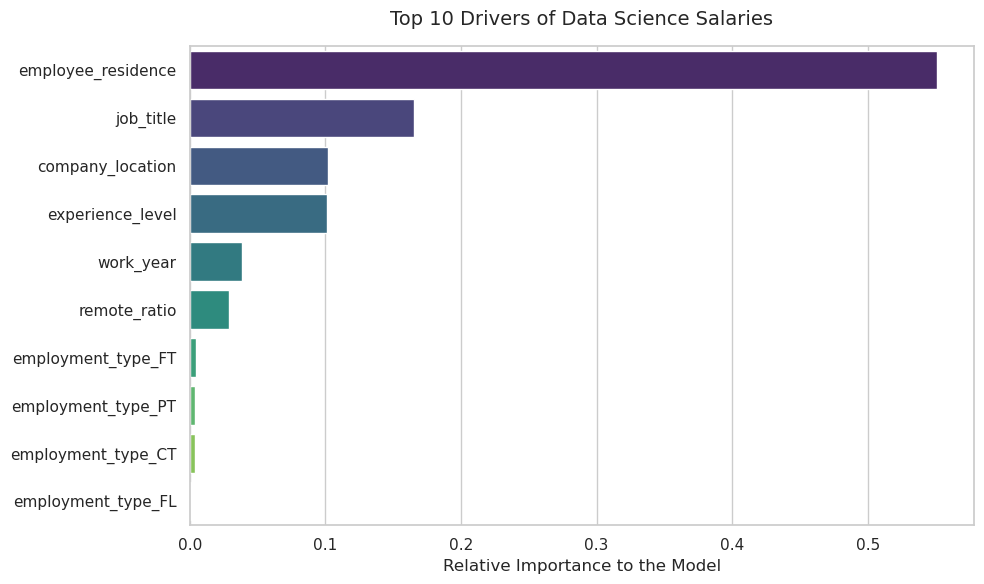

In [25]:
# 4. Plot the Top 10 Most Important Features (Future-proofed)
plt.figure(figsize=(10, 6))

importances = pd.read_csv("model/feature_importances.csv")

sns.barplot(
    data=importances.head(10),
    x='Importance', 
    y='Feature', 
    hue='Feature',     # Satisfies the new Seaborn rule
    legend=False,      # Prevents a redundant legend box from appearing
    palette='viridis'
)

plt.title('Top 10 Drivers of Data Science Salaries', fontsize=14, pad=15)
plt.xlabel('Relative Importance to the Model')
plt.ylabel('')
plt.tight_layout()
plt.show()